# 6. Fluctuation statistics (N=10000)

We compute it from scratch (for that we first need the average data, obtained from roughness calculations

In [1]:
import numpy as np
import pandas as pd
from TracyWidom import TracyWidom
import os

from surface_functions import compute_surface_variance, compute_surface_roughness
from fluctuation_functions import compute_rescaled_phases_at_index, normalized_tw_pdf

In [2]:
z_dict = {"TimeDep": {"EW": 2, "KPZ": 3/2}, "Columnar": {"EW": 2, "KPZ": 1.36}}
alpha_dict = {"TimeDep": {"EW": 1/2, "KPZ": 1/2}, "Columnar": {"EW": 3/2, "KPZ": 1.07}}
alpha_s_dict = {"TimeDep": {"EW": 1/2, "KPZ": 1/2}, "Columnar": {"EW": 3/2, "KPZ": 1.4}}  # anomalous scaling, only for columnar noise
alpha_loc_dict = {"TimeDep": {"EW": 1/2, "KPZ": 1/2}, "Columnar": {"EW": 1, "KPZ": 0.96}} # anomalous scaling, only for columnar noise
beta_dict = {"TimeDep": {"EW": alpha_dict["TimeDep"]["EW"]/z_dict["TimeDep"]["EW"], "KPZ": alpha_dict["TimeDep"]["KPZ"]/z_dict["TimeDep"]["KPZ"]}, 
             "Columnar": {"EW": alpha_dict["Columnar"]["EW"]/z_dict["Columnar"]["EW"], "KPZ": alpha_dict["Columnar"]["KPZ"]/z_dict["Columnar"]["KPZ"]}}
delta_to_label = {"0": "EW", "atan5": "KPZ"}

In [3]:
# Adjustment to the crossover time: t_x = tx * L**z (BY HAND for Ks=[1,40])
tx = {"TimeDep": {"EW": 1/100, "KPZ": 1/10}, "Columnar": {"EW": 1/1500, "KPZ": 1/80}}

## Dataframe computations

In [5]:
summary_rows = []
for typenoise in ["TimeDep", "Columnar"]:
    
    for delta, deltaname in zip([0, np.arctan(5)], ["0", "atan5"]):

        path = f"../Simulations_1D/Output{typenoise}/all_simulations_delta{deltaname}.pkl"
        if not os.path.exists(path):
            print(f"File {path} not found, skipping.")
            continue


        # Load previously saved simulations
        df = pd.read_pickle(path)

        roughness_list = []  # used to compute per-sim roughness
        variance_list = []   # used to compute per-sim variance
        datapoint_list = []

        skip = 0
        # Loop over simulations (one per seed / row)
        for _, row in df.iterrows():
            t = row["t"]
            phases = row["phases"]
            
            # if row["L"] != 10000:
            #     skip += 1
            #     continue

            # ensure array, not list-of-lists
            variance = np.asarray(compute_surface_variance(phases), dtype=float)
            roughness = np.asarray(compute_surface_roughness(phases), dtype=float)

            variance_list.append(variance)
            roughness_list.append(roughness)
            datapoint_list.append(len(roughness))
        
        print(f"## {typenoise} – Delta {deltaname} -- Skipped: {skip}")

        # Avoid chained-assignment issues
        df = df.copy()
        df["variance"] = variance_list
        df["roughness"] = roughness_list
        df["datapoints"] = datapoint_list

        # DO NO SAVEEE
        # Save back the updated simulations DataFrame (with roughness column)
        # df.to_pickle(path)

        ## AVERAGE ROUGHNESS PER (K, L, T) ##
        # group by K, L, T and compute mean roughness for each group
        for (K_val, L_val, T_val), group in df.groupby(["K", "L", "T"]):

            if L_val != 10000:
                continue

            rough_arrays = [np.asarray(r, dtype=float) for r in group["roughness"]]
            mean_roughness = np.mean(np.stack(rough_arrays, axis=0), axis=0)

            variance_arrays = [np.asarray(r, dtype=float) for r in group["variance"]]
            mean_roughness2 = np.sqrt(np.mean(np.stack(variance_arrays, axis=0), axis=0))

            # assume all t are identical within group; take the first
            t = group.iloc[0]["t"]
            seed_list = group.index.tolist()
            M = len(seed_list) 

            avg_id = f"{typenoise}_delta{deltaname}_L{L_val}_K{K_val}_T{T_val}_M{M}"

            summary_rows.append(
                {
                    "avg_id": avg_id,
                    "typenoise": typenoise,
                    "delta": delta,
                    "deltaname": deltaname,
                    "K": K_val,
                    "L": L_val,
                    "t": t,
                    "M": M,
                    "T": T_val,
                    "mean_roughness": mean_roughness,
                    "mean_roughness2": mean_roughness2,
                }
            )

## TimeDep – Delta 0 -- Skipped: 0
## TimeDep – Delta atan5 -- Skipped: 0
## Columnar – Delta 0 -- Skipped: 0
## Columnar – Delta atan5 -- Skipped: 0


In [6]:
# Note: we start from scratch the average DataFrame (each time this code is run)
avg_df = pd.DataFrame()
# avg_df_path = "../Simulations_1D/average_simulations.pkl"

# Build/update AverageSims dataframe
if summary_rows:
    new_avg = pd.DataFrame(summary_rows).set_index("avg_id")
    if avg_df.empty:
        avg_df = new_avg
    else:
        # ensure we have an index; if not, give it one
        if avg_df.index.name is None:
            avg_df = avg_df.copy()
            avg_df.index.name = "avg_id"
        avg_df = pd.concat([avg_df, new_avg])
        # keep last occurrence per avg_id
        avg_df = avg_df[~avg_df.index.duplicated(keep="last")]

    # DO NOT SAVE!!
    # avg_df.to_pickle(avg_df_path)
    # print(f"Saved average simulations ({len(df)}) to:", avg_df_path)

In [7]:
len(avg_df)

4

In [8]:
summary_rows = []
for typenoise in ["TimeDep", "Columnar"]:
    
    for delta, deltaname in zip([0, np.arctan(5)], ["0", "atan5"]):

        path = f"../Simulations_1D/Output{typenoise}/all_simulations_delta{deltaname}.pkl"
        if not os.path.exists(path):
            print(f"File {path} not found, skipping.")
            continue

        print(f"## {typenoise} – Delta {deltaname}")

        # Load previously saved simulations
        df = pd.read_pickle(path)

        beta = beta_dict[typenoise][delta_to_label[deltaname]]
        z = z_dict[typenoise][delta_to_label[deltaname]]

        ## AVERAGE FLUCTUATION STATISTICS PER (K, L, T) ##
        # group by K, L, T and compute fluctuation statistics for each group
        for (K_val, L_val, T_val), group in df.groupby(["K", "L", "T"]):

            if L_val != 10000:
                continue
                
            t_cross = tx[typenoise][delta_to_label[deltaname]] * (L_val ** z)
            
            per_seed_varphis = []
            for _, row in group.iterrows():
                t = np.asarray(row["t"])
                phases = np.asarray(row["phases"])

                t0_idx = int(np.argmin(np.abs(t - 50)))-2 # optional, where to start.

                for ti_idx in range(t0_idx + 1, len(t)):
                    if t[ti_idx] < t_cross:
                        v = compute_rescaled_phases_at_index(phases, t, t0_idx, ti_idx, beta=beta)
                        per_seed_varphis.append(v)

            varphis_full = np.ravel(per_seed_varphis)
            avg_id = f"{typenoise}_delta{deltaname}_L{L_val}_K{K_val}_T{T_val}_M{len(group)}"

            summary_rows.append(
                {
                    "avg_id": avg_id,
                    "varphis_full": varphis_full,
                }
            )

## TimeDep – Delta 0
## TimeDep – Delta atan5
## Columnar – Delta 0
## Columnar – Delta atan5


In [16]:
avg_df_path = "../Simulations_1D/fluctuations_N10000.pkl"
# avg_df = pd.read_pickle(avg_df_path)

new_avg = pd.DataFrame(summary_rows).set_index("avg_id")
avg_df.loc[new_avg.index, "varphis_full"] = new_avg["varphis_full"]

avg_df.to_pickle(avg_df_path)

## Inspection of the computed quantities

In [4]:
import matplotlib.pyplot as plt
import scienceplots

plt.style.use(["science","no-latex"])

%load_ext autoreload
%autoreload 2

from fluctuation_functions import plot_fluctuations_pdf, plot_log_fluctuations_pdf

In [5]:
avg_df_path = "../Simulations_1D/fluctuations_N10000.pkl"
avg_df = pd.read_pickle(avg_df_path)

In [6]:
L = 10000
T = 20000
Ks = [1, 40]

Skewness (TimeDep, 0): -0.0010418282389859463
Skewness (TimeDep, atan5): 0.34800264858424423
Skewness (Columnar, 0): 0.0008315088767274308
Skewness (Columnar, atan5): 0.3024807602530283


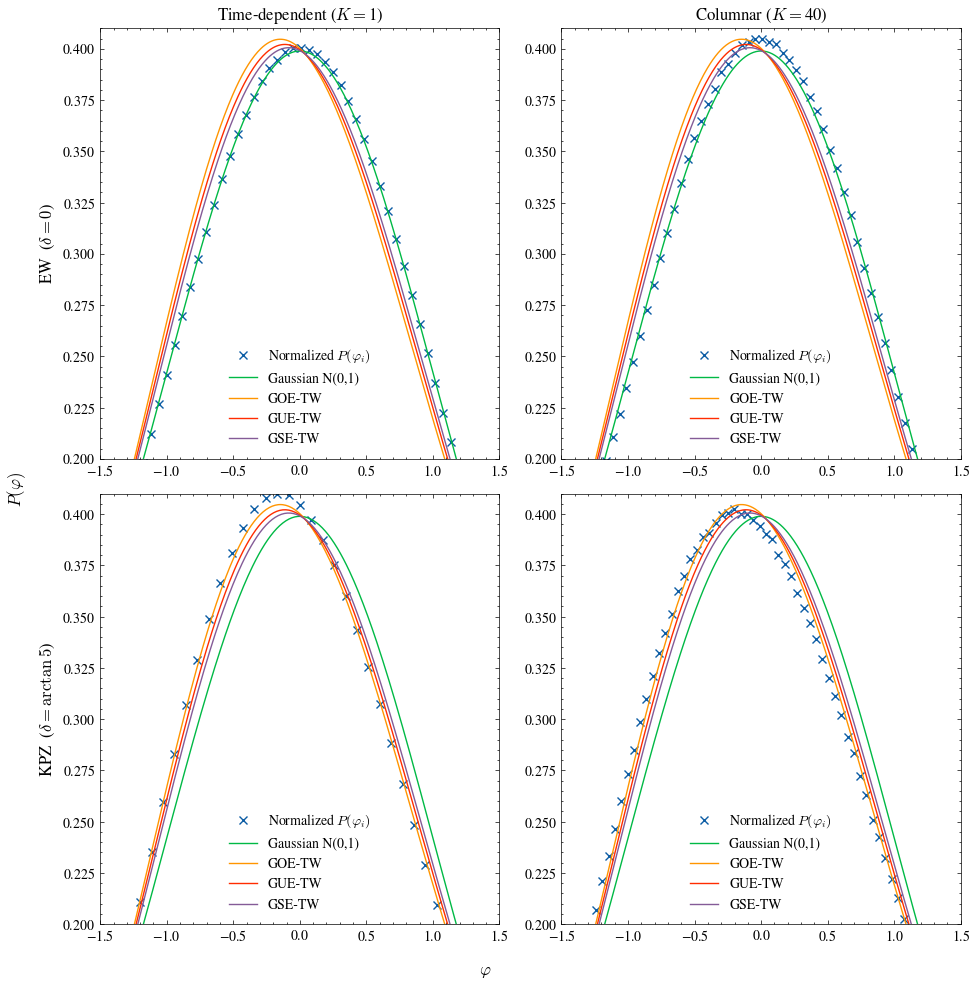

In [9]:
plot_fluctuations_pdf(avg_df, L, T, tx, Ks, save=True)

WHY DO THEY USE MUCH HIGHER COUPLINGS? (Columnar, delta = 0 -> K = 110)

### Tail of the distrbutions (in log scale)

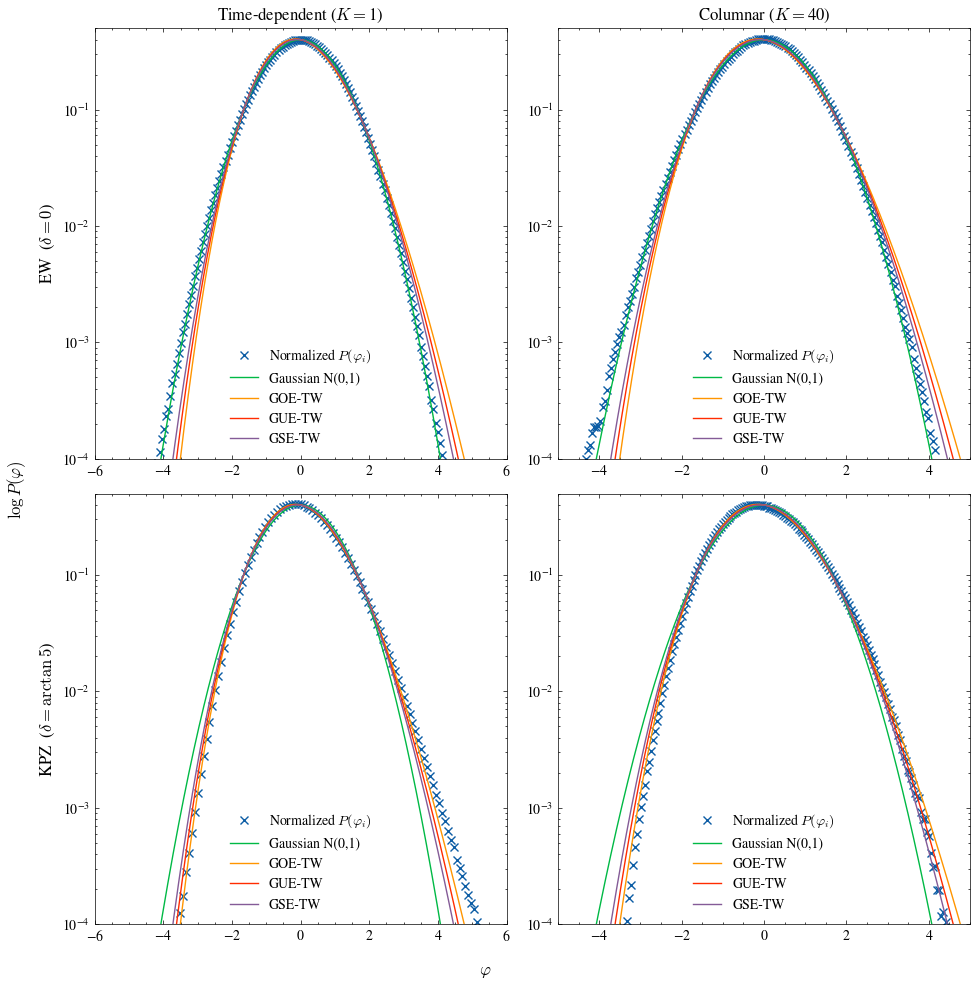

In [11]:
plot_log_fluctuations_pdf(avg_df, L, T, tx, Ks, save=True)